##### data set link - "https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification"

In [138]:
import re
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




In [139]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="darkgrid")

plt.rcParams.update({'axes.titlesize': 14
                     , 'axes.labelsize': 12
                     , 'xtick.labelsize': 10
                     , 'ytick.labelsize': 10
                     , 'legend.fontsize': 10
                     , 'figure.titlesize': 16})


In [140]:
df=pd.read_csv('../Data set/WELFake_Dataset.csv') 

In [141]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Target 
0=fake
1=real

In [142]:
#drop unnecessary columns
df.drop(columns=['Unnamed: 0'], inplace=True)

In [143]:
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [144]:
print(df.value_counts('label'))

label
1    37106
0    35028
Name: count, dtype: int64


In [145]:
# split 15000 data to my model

df_fake = df[df['label'] == 0].sample(10000, random_state=42)
df_real = df[df['label'] == 1].sample(10000, random_state=42)

In [146]:
df=(
pd.concat([df_fake, df_real], 
          axis=0).sample(frac=1, random_state=42).
          reset_index(drop=True)
)

In [147]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 20000
Number of columns: 3


In [148]:
print(df.value_counts('label'))

label
0    10000
1    10000
Name: count, dtype: int64


In [149]:
df.isnull().sum()

title    133
text      11
label      0
dtype: int64

In [150]:
df.dropna(inplace=True)

In [151]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [152]:
df.value_counts('label')

label
0    10000
1     9856
Name: count, dtype: int64

Text Cleaning

In [153]:
df['text'].head()

0    Did America really expect this racist, Communi...
1    (Reuters) - Pennsylvania Governor Tom Wolf sig...
2    WASHINGTON (Reuters) - U.S. lawmakers signaled...
3    BEIRUT (Reuters) - The death toll from air str...
4    A House Tea Party Republican declared that con...
Name: text, dtype: object

""" 
-lowercasing
-romove urls
-romove html tags
-keep letter/ number and basic punctuations
-normalize space
"""

In [154]:
def clean_text(s: str) -> str:
    """
    simple text cleaning :
    - lower case
    - remove URLs
    - remove html tags
    - remove punctuation
    - keep letters and numbers and basic punctuation
    - normalize spaces
    """
    if pd.isna(s):
        return ""   
    s = str(s).lower()
    s = re.sub(r'http\S+', '', s)  # remove URLs
    s = re.sub(r'<.*?>', '', s)  # remove HTML tags
    s = re.sub(r'[^\w\s.,!?;:()\-]', '', s)  # keep letters, numbers, and basic punctuation
    s = re.sub(r'\s+', ' ', s).strip()  # normalize spaces
    return s 

In [155]:
#combine title and text columns & apply cleaning text function
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].apply(clean_text)

In [156]:
df.head() 

,title,text,label,content
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breakingobamas war on cops: another cop ambush...
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...


In [157]:
# add additional columns for analysis
df['title_len_char'] = df['title'].str.len()
df['text_len_char'] = df['text'].str.len()
df['content_len_words'] = df['content'].str.split().apply(len) 



In [158]:
df.head()

,title,text,label,content,title_len_char,text_len_char,content_len_words
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breakingobamas war on cops: another cop ambush...,134,5854,1029
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...,49,751,115
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...,55,2736,468
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...,55,1775,300
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...,100,3451,588


In [161]:
num_cols = ['title_len_char', 'text_len_char', 'content_len_words']

In [162]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_char,19856.000,76.993,25.072,4.000,62.000,73.000,89.000,286.000
text_len_char,19856.000,3283.625,3658.956,1.000,1414.750,2435.000,4081.500,115372.000
content_len_words,19856.000,552.878,611.225,0.000,243.000,411.000,681.000,20863.000


### Data Visuzlaization

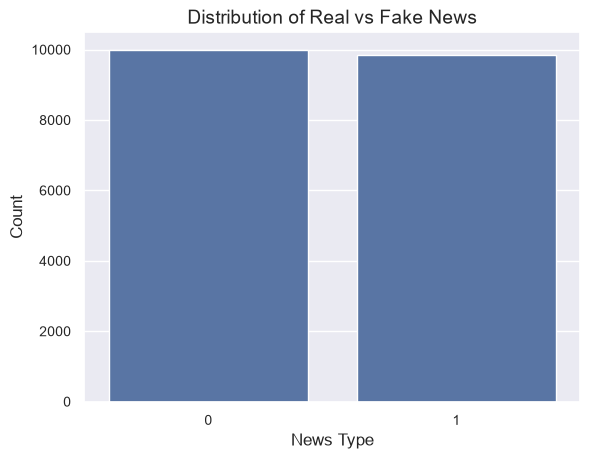

In [163]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Real vs Fake News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

In [ ]:
fake_len = df[df['label'] == 0]['content_len_words'].values
real_len = df[df['label'] == 1]['content_len_words'].values

plt.figure(figsize=(10, 6))
plt.boxplot([fake_len, real_len],
            tick_labels=['Fake News', 'Real News'])  # Use 'tick_labels' for newer Matplotlib versions

plt.title('Content Length Distribution for Fake vs Real News')
plt.xlabel('News Type')
plt.ylabel('Content Length (Words)')


KeyError: 'content_word_count'

In [113]:
print(fake_len)

[ 873   24  813   67  728  944   88 2049  151 1407  178  405  451  464
  468   98   94  266 1093  447  225  465 1235  460  409  874  871  415
  395  598  843  725  693  112  427 1292   72  701  597   53  846  100
  816  252 1263  162  970   89  378  680  517  917  700  670 1820   41
  173  598 1137 1226  660  857  187  180   77   65 1343  329  204  297
  115  522  322  253  147  525  131 1117   88   23  786  375  485   81
  208  251  219  530  394  657 1109  423  105  786 1469  834  537   82
  693   85 1807  868   79 1473  304  355  567  468  410 1917  357  485
  569  881  796  660  176  311  410  667  735 1294  814  286  184  512
  794  382  444  948  275  199  531   81  520  809  637  314  592  317
  619  401  801 1035   65  895  204  689  714  378  431 1143  320  104
  310  236  415  824  200  292  333  309  314  641   74  417 1617  885
  463  483   74   85  266 1446 1431  398   74  112  371  394  661   98
   93  309  488  420 1323  349  385  680  646 1076 1247   89  639 1273
  877 